[2026-08-02 11:17:25] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-06-30 23:59:59
[2026-08-02 11:17:39] [info     ] 因子 shape: (116730, 3)
        date instrument    factor
0 2024-01-02  000006.SZ -0.133333
1 2024-01-02  000012.SZ -0.571427
2 2024-01-02  000016.SZ -0.000000
3 2024-01-02  000019.SZ -0.800001
4 2024-01-02  000025.SZ -0.727271
5 2024-01-02  000028.SZ -0.628099
6 2024-01-02  000029.SZ -0.030304
7 2024-01-02  000030.SZ -0.666667
count    116730.000000
mean         -0.466767
std           0.318086
min          -1.000000
25%          -0.750000
50%          -0.444444
75%          -0.171430
max          -0.000000
Name: factor, dtype: float64
[2026-08-02 11:17:39] [info     ] 读取因子库...
[2026-08-02 11:17:39] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-02 11:17:41] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-02 11:17:41] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-02 11:17:41] [info     ] 对齐中证1000

时段,IC
2024-01-15~2024-02-08,0.0144

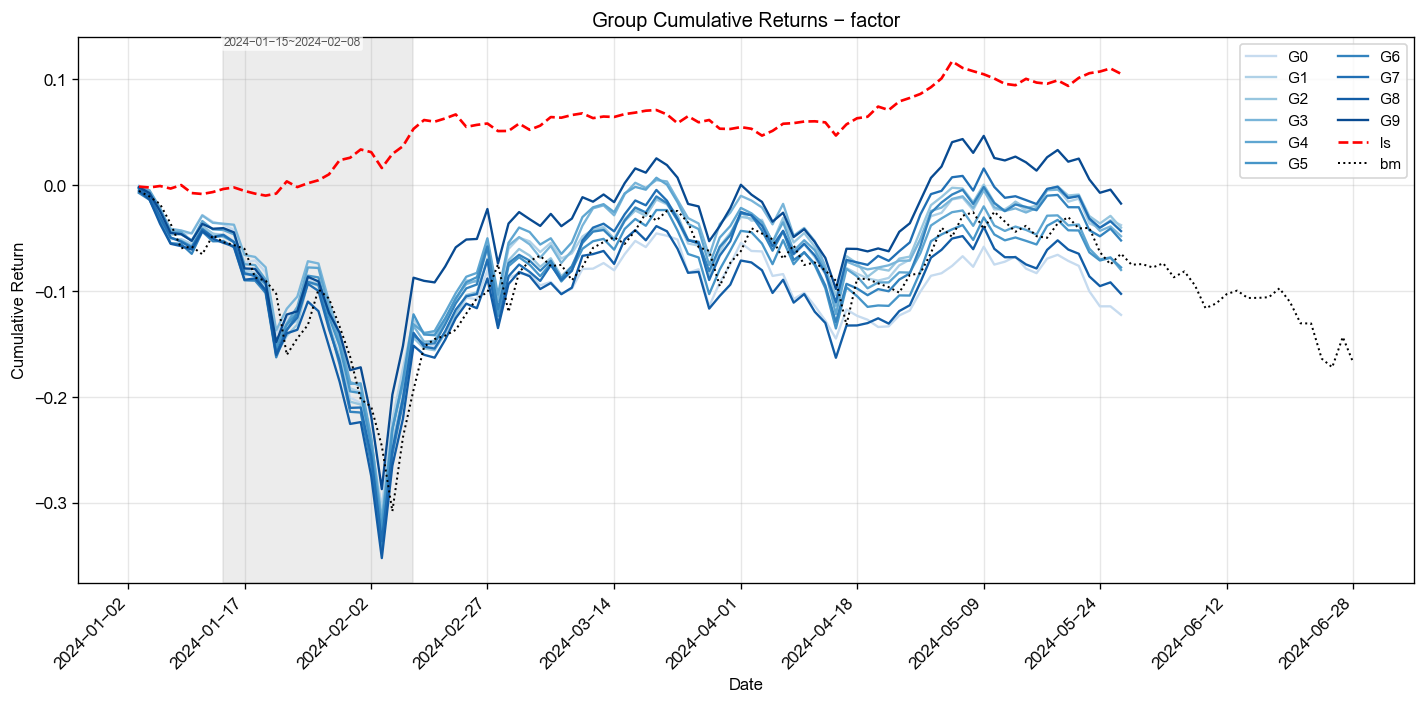
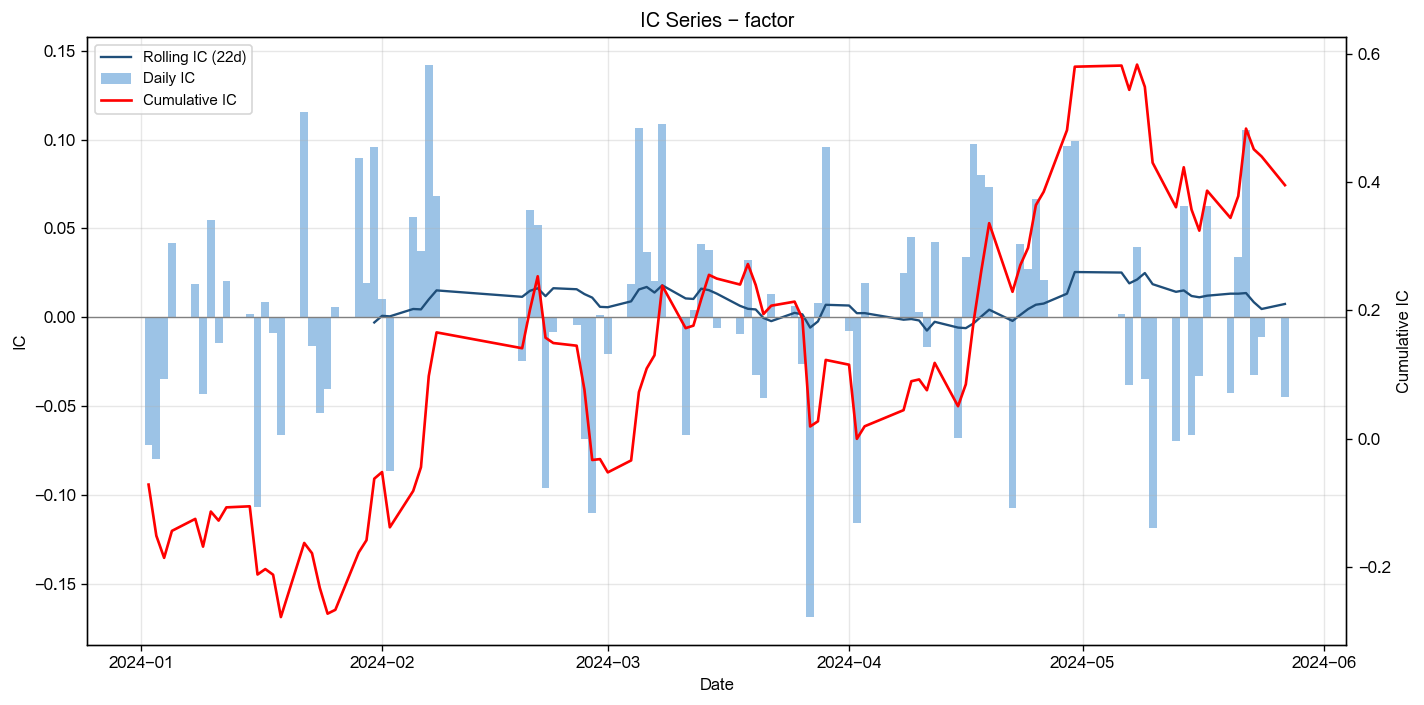
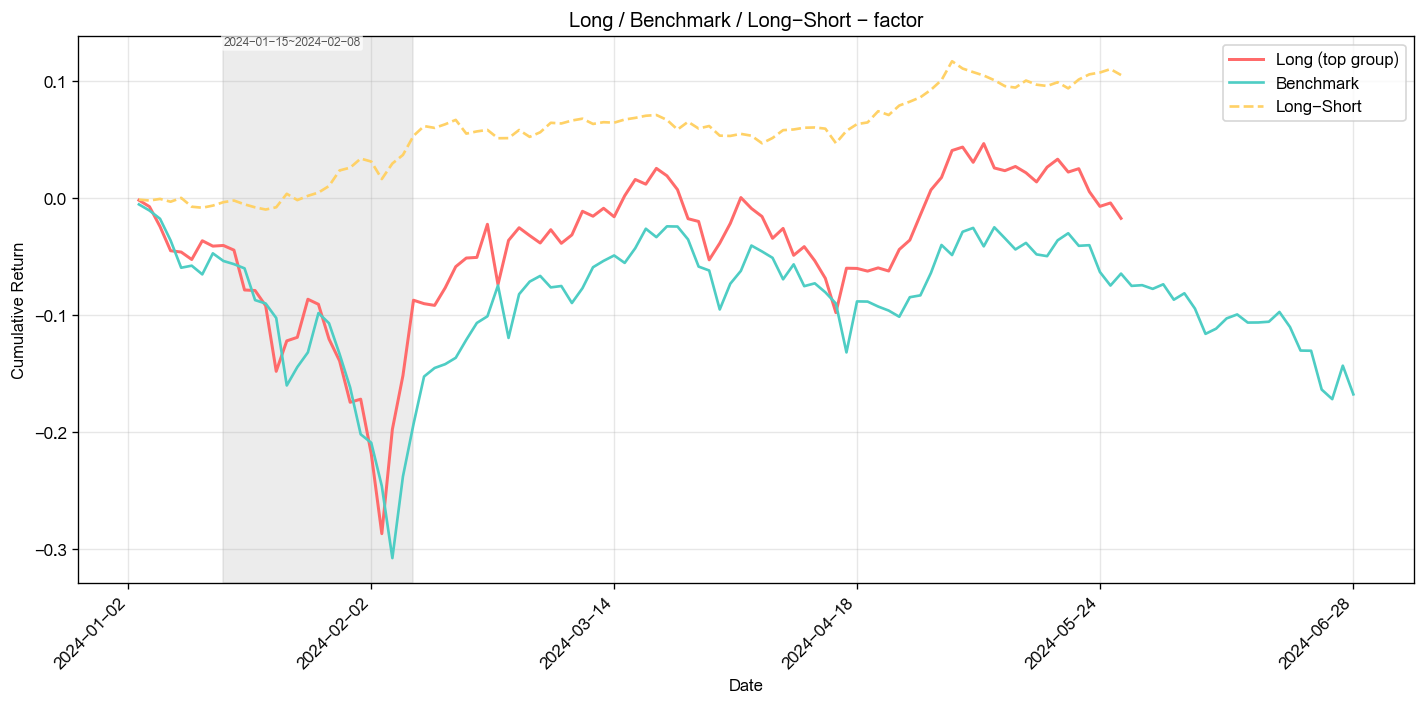
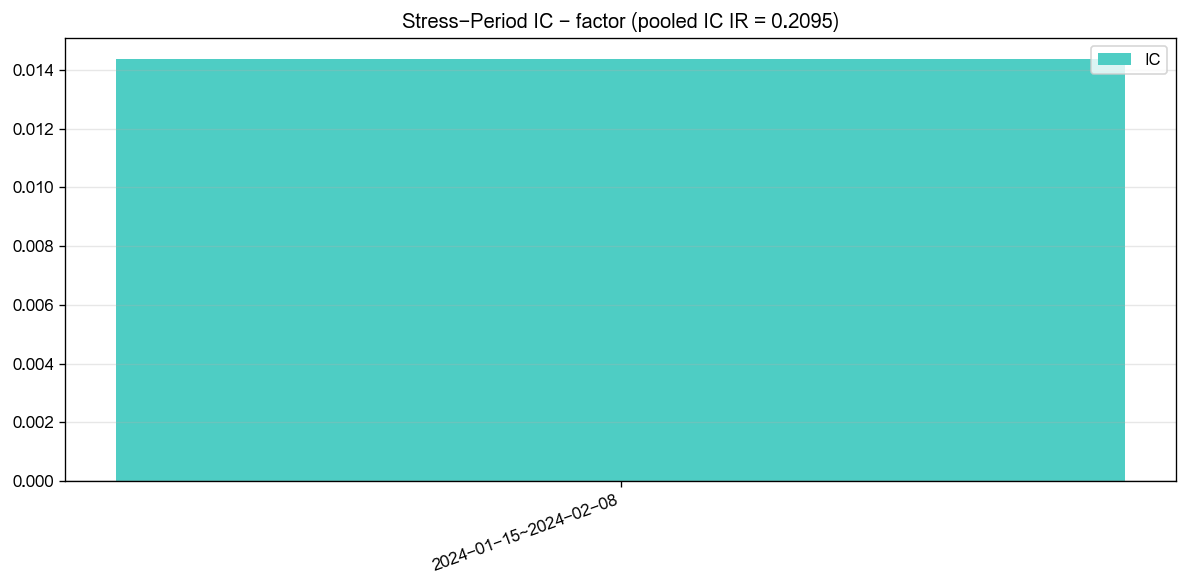
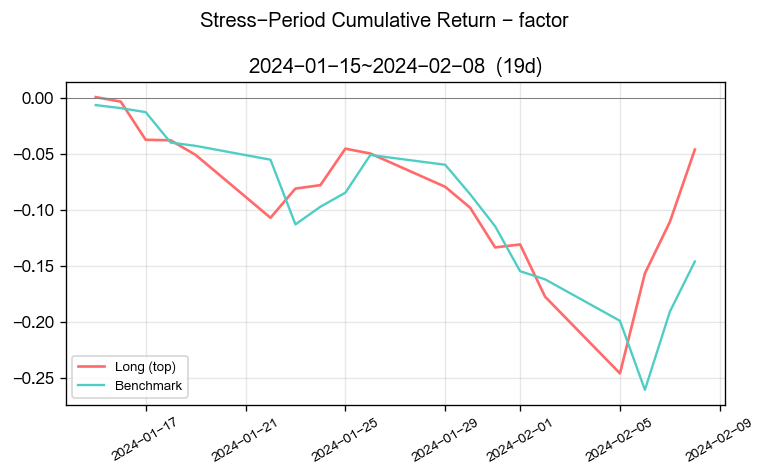

[2026-08-02 11:19:50] [info     ] ========== 因子池回归 ==========
[2026-08-02 11:19:51] [info     ] 加载 T+1 收益数据完成                  end_date=2024-06-28 instrument_count=1103 rows=138298 start_date=2024-01-02
[2026-08-02 11:19:51] [info     ] 获取收益率数据, 耗时: 0.5615 秒
[2026-08-02 11:19:52] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.6331 秒
[2026-08-02 11:19:52] [info     ] 统计 回归结果, 耗时: 0.0079 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,6.2260,0.0198,0.0032,1.0000
2,gross_profit_rate_ttm,4.5434,0.0112,0.0025,1.0000
3,kdj_d_9_3_3,4.4691,0.0180,0.0040,1.0000
4,net_profit_rate_ttm,2.9997,0.0061,0.0020,1.0000
5,macd_dea_12_26_9,2.7936,0.0093,0.0033,1.0000
6,pe_ttm,2.4126,0.0012,0.0005,1.0000
7,netflow_amount_main,2.3126,0.0379,0.0164,1.0000
8,roa_avg_ttm,2.1884,0.0210,0.0096,1.0000
9,rsi_12,2.1433,0.0504,0.0235,1.0000
10,netflow_amount_rate_main,2.0451,0.0052,0.0026,1.0000

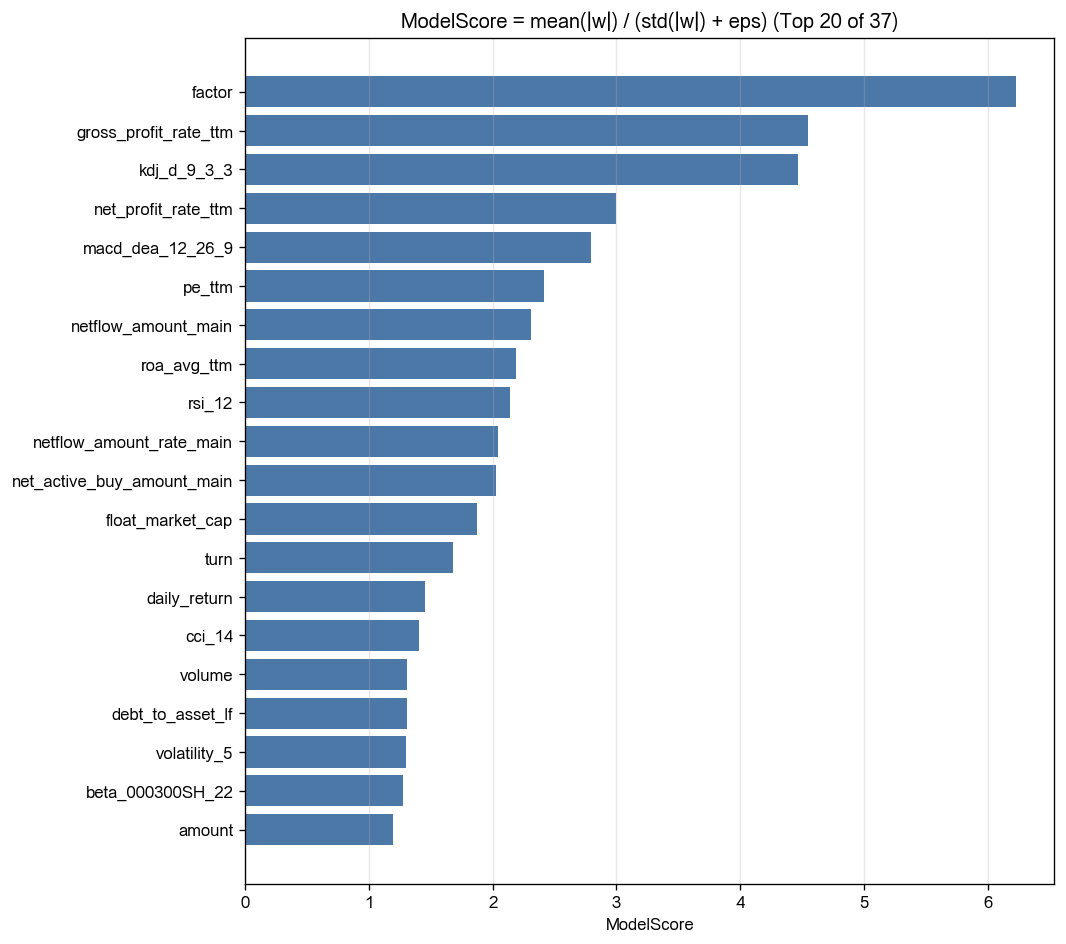
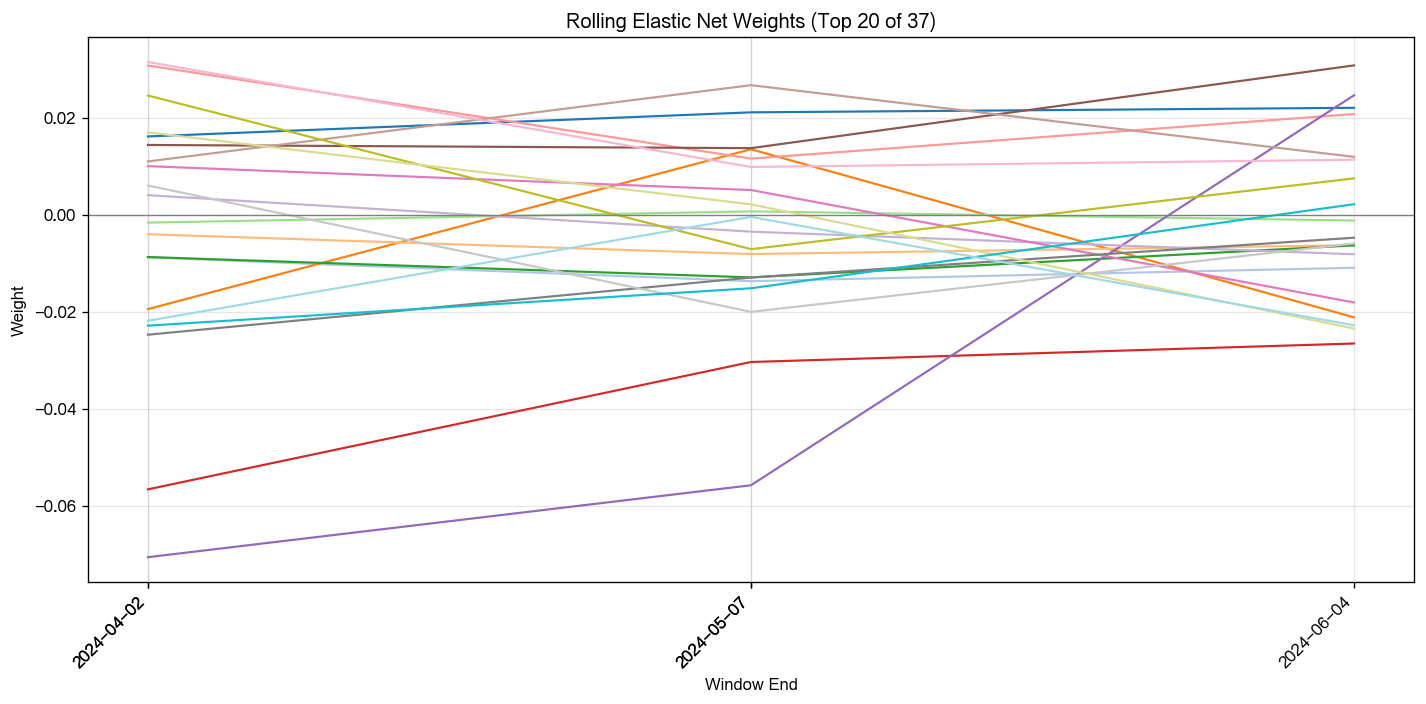
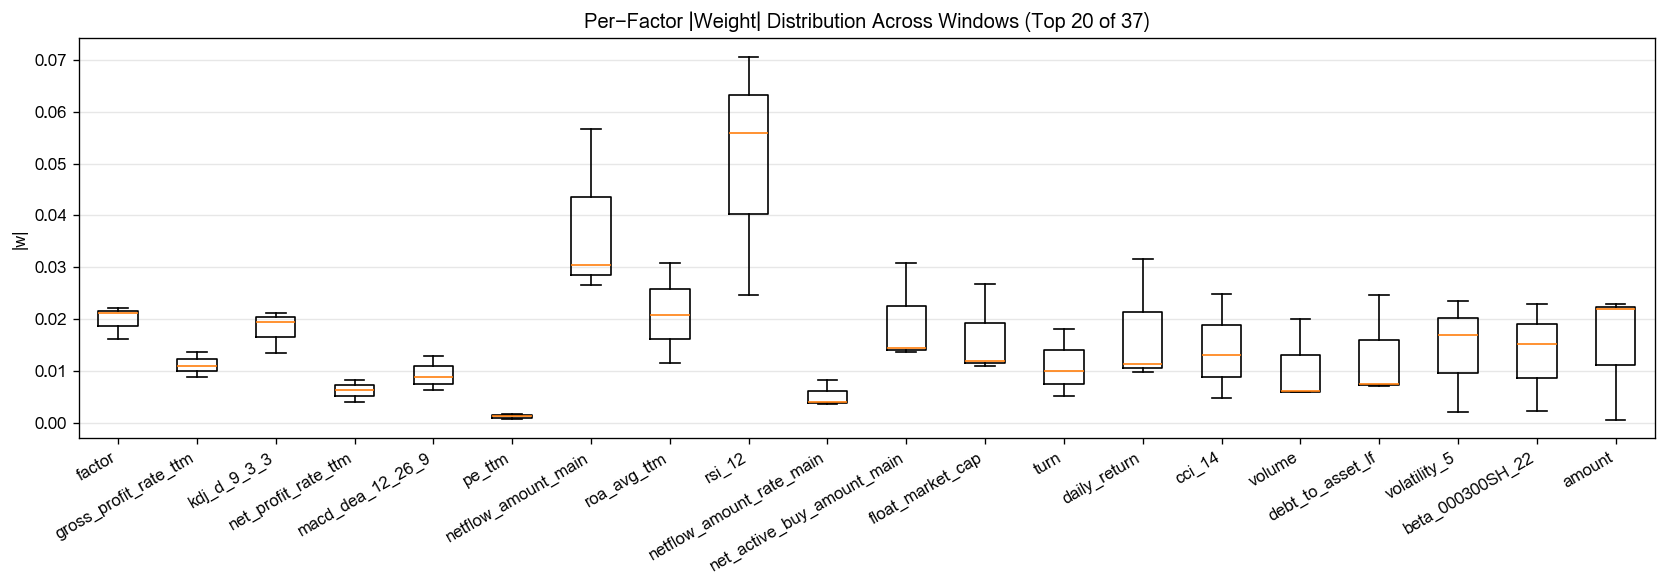
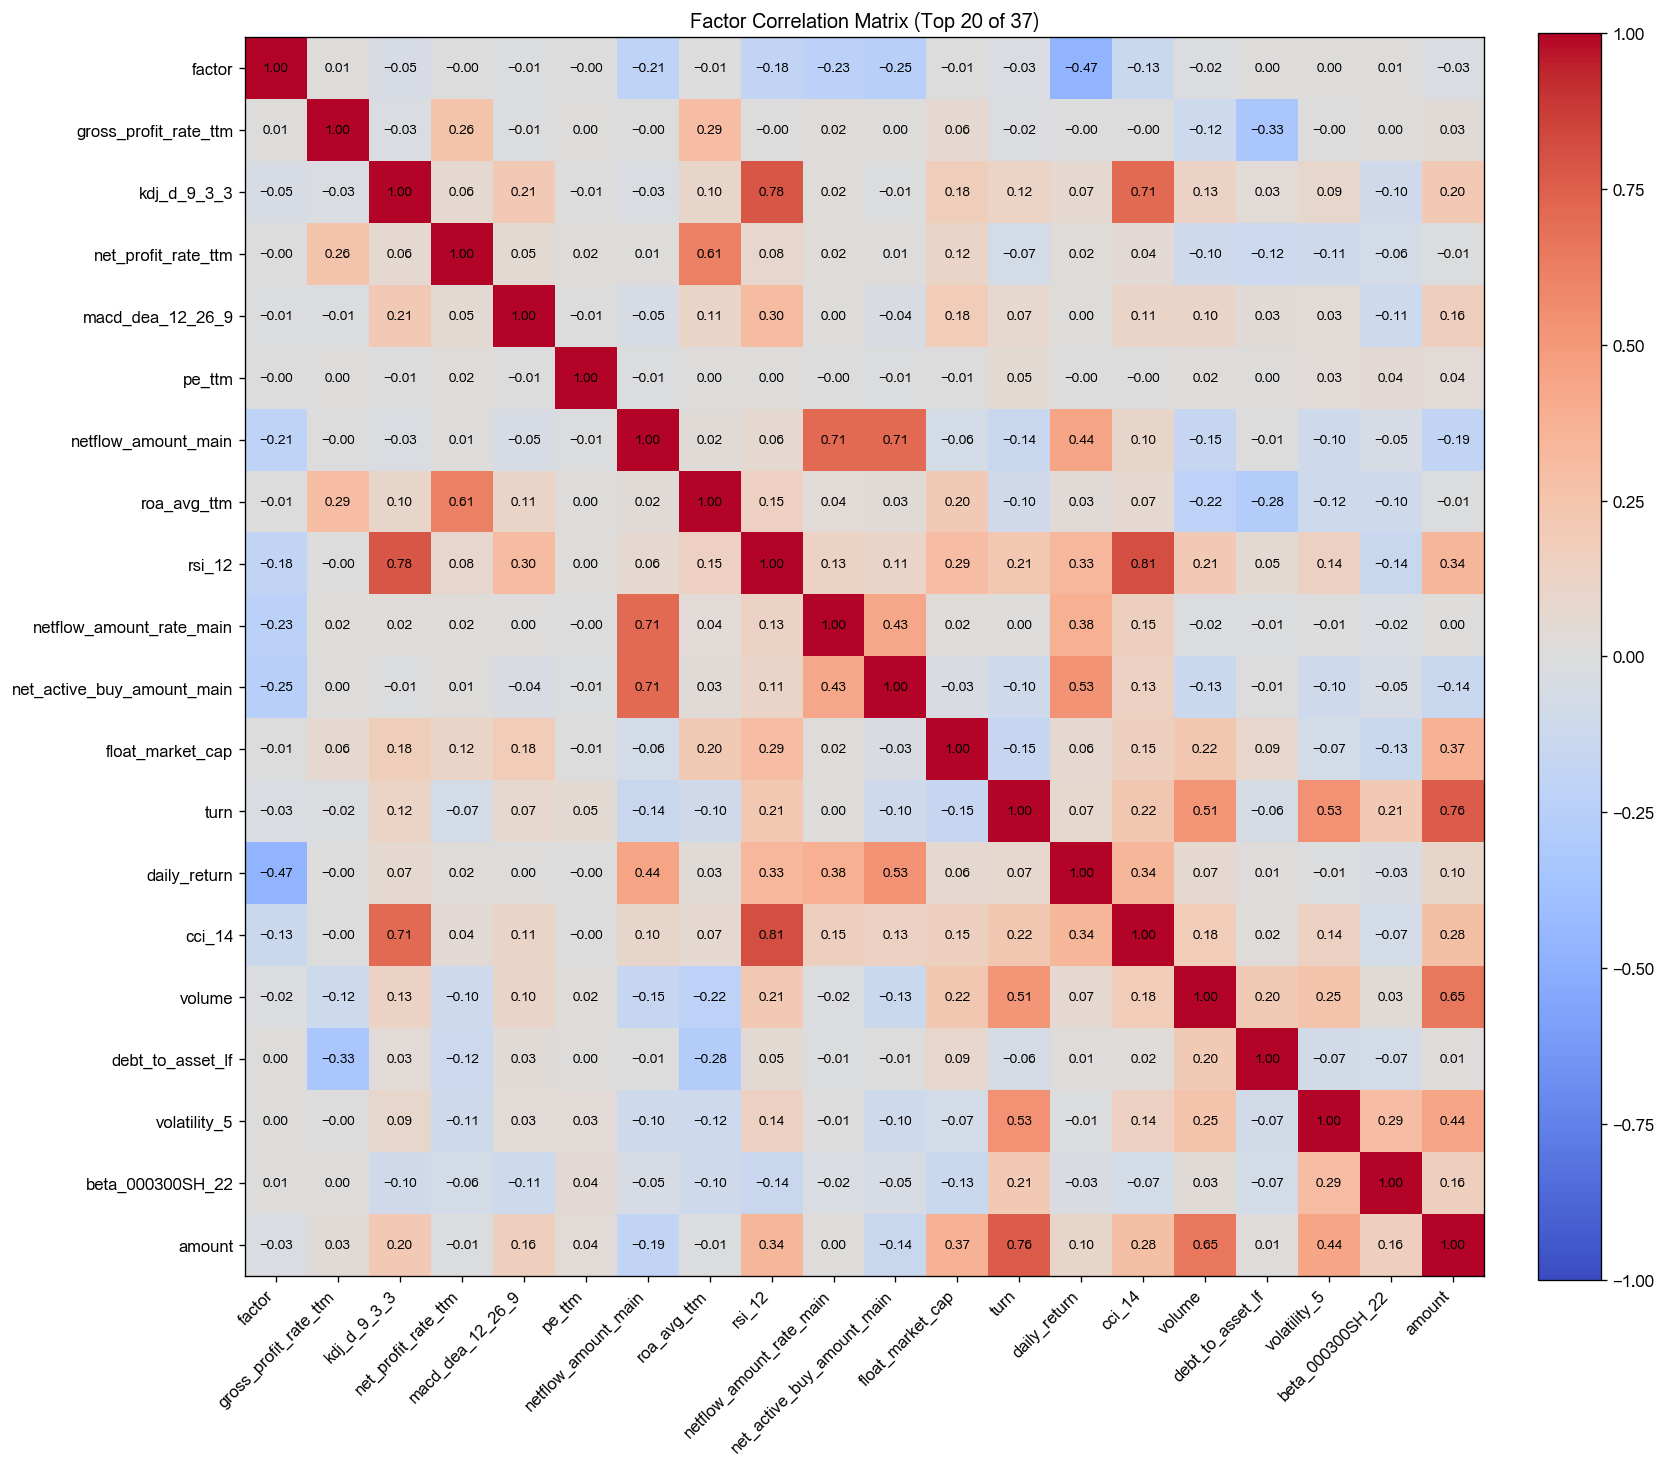

[2026-08-02 11:19:54] [warning  ] 返回的Outputs实例(size=16372817) 大于 64K, 将不会被缓存
[2026-08-02 11:19:54] [info     ] bigalpha_eval.v4 运行完成 [133.720s].


In [1]:
def main(datasources, start_date, end_date):
    """
    Intraday Close Location Value (CLV) factor
    
    CLV = (close - low) / (high - low)
    Higher value = closed near the day's high
    
    This version uses the whole trading day high/low/close from 1-min bars.
    Direction is set as mean-reversion (negative sign) which is usually better
    for next-day prediction in A-shares.
    """
    import pandas as pd
    import dai

    bar1m = datasources["bar1m"]

    LOOKBACK_DAYS = 1
    query_start_date = (pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK_DAYS)).strftime("%Y-%m-%d %H:%M:%S")

    sql = f"""
    WITH daily_bar AS (
        SELECT
            strftime(date, '%Y-%m-%d') AS trading_day,
            instrument,
            MAX(high)   AS day_high,
            MIN(low)    AS day_low,
            LAST(close ORDER BY date) AS day_close,          -- last available close of the day
            SUM(volume) AS day_volume
        FROM {bar1m}
        WHERE high > 0 AND low > 0 AND close > 0
        GROUP BY trading_day, instrument
        HAVING COUNT(*) >= 60                                -- enough minutes
    )
    SELECT
        CAST(trading_day AS DATETIME) AS date,
        instrument,
        -- Classic CLV, then force mean-reversion direction
        -1.0 * (day_close - day_low) / (day_high - day_low + 1e-8) AS factor
    FROM daily_bar
    WHERE day_high > day_low                                 -- avoid zero-range days
    ORDER BY trading_day, instrument
    """

    df = dai.query(
        sql,
        filters={"date": [query_start_date, end_date]},
        compression=True
    ).df()

    # Align to CSI 1000 constituents
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()

    df = pd.merge(df, stk_pool, how="inner", on=["date", "instrument"])

    # Clean
    df = df.replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["factor"])

    return df[["date", "instrument", "factor"]]


if __name__ == "__main__":
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}

    # Test period
    start_date = "2024-01-01 00:00:00"
    end_date   = "2024-06-30 23:59:59"

    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)
    logger.info(f"因子 shape: {factor_data.shape}")
    print(factor_data.head(8))
    print(factor_data["factor"].describe())

    logger.info("读取因子库...")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )

